# Ensemble Feature Combination Analysis

This notebook analyzes the performance of different feature combinations for EEG classification using ensemble methods. It loads prediction results, computes various metrics (accuracy, balanced accuracy, F1, AUC, AUPRC, etc.), and visualizes the best combinations based on these metrics.

Key steps:
- Load prediction files for all feature combinations
- Compute and aggregate performance metrics
- Identify the best combinations for each combination length
- Visualize ROC curves for the best combinations

In [1]:
# Imports and Setup
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix,
    balanced_accuracy_score, average_precision_score, auc as sk_auc
    )

# Available data paths
available_paths = [ '/space/gzanardini/emc/emc_ensemble_retrain/',
                    '/space/gzanardini/emc/emc_ips+bg/',
                    '/space/gzanardini/tuh/tuh_ensemble_retrain/',
                    '/space/gzanardini/tuh/tuh_ensemble_retrain_noieds/']

# '/space/gzanardini/tuh/tuh_ensemble_bucket/',
#                     '/space/gzanardini/tuh/tuh_ensemble_penalty/',
#                     '/space/gzanardini/tuh/tuh_ens_bucket_noIED/',
#                     '/space/gzanardini/tuh/tuh_ens_penalty_noIED/',
#                     '/space/gzanardini/emc/emc_ensemble_bucket/',
#                     '/space/gzanardini/emc/emc_ensemble_penalty/',

#'/space/gzanardini/tuh/tuh_ensemble_bucket/', 
#'/space/gzanardini/tuh/tuh_ensemble_logits/',
#'/space/gzanardini/tuh/tuh_ens_bucket_noIED/',
#'/space/gzanardini/tuh/tuh_ens_penalty_noIED/',
#'/space/gzanardini/emc/emc_ensemble_bucket/',
#'/space/gzanardini/emc/emc_ensemble_logits/',
#'/space/gzanardini/emc/emc_ensemble_bucket_2/',
#'/space/gzanardini/emc/emc_ensemble_bucket_real/',
#'/space/gzanardini/emc/emc_ensemble_bucket/' ,
#'/space/gzanardini/emc/emc_ensemble_penalty/,
#'/space/gzanardini/emc/emc_concat/'
    
# ]

print("Available data paths:")
for i, path in enumerate(available_paths):
    print(f"{i+1}. {path}")

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)

Available data paths:
1. /space/gzanardini/emc/emc_ensemble_retrain/
2. /space/gzanardini/emc/emc_ips+bg/
3. /space/gzanardini/tuh/tuh_ensemble_retrain/
4. /space/gzanardini/tuh/tuh_ensemble_retrain_noieds/


In [2]:
# Utility Functions for ROC and Display
pd.options.display.max_columns = 999
pd.options.display.max_rows = None
np.set_printoptions(threshold=np.inf)

plt.style.use('ggplot')

def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """Linear interpolation of TPR at FPR = x between two points."""
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)

def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """Find/interpolate TPR at a specific FPR. Assumes fpr_arr is sorted ascending."""
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    if i < 0:  # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    return interpolate(fpr_arr[i], tpr_arr[i], fpr_arr[i + 1], tpr_arr[i + 1], fprsample)

def vertical_avg_roc(roc_data):
    """Average ROC curve vertically across multiple ROC curves."""
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)

    fprs = np.sort(np.unique(fprs))
    tprs = np.zeros(shape=(len(roc_data), len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx, (fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr

def calculate_bac(labels, scores, sens_thresh):
    """
    Calculate balanced accuracy with a sensitivity threshold.
    Returns: (bac, fpr, tpr, thresholds)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    threshold_sensitivity = thresholds[np.where(tpr >= sens_thresh)[0][0]]
    adjusted_predictions = (scores >= threshold_sensitivity).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, adjusted_predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    bac = ((sensitivity + specificity) / 2)
    return bac, fpr, tpr, thresholds

def compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6):
    """
    Compute the slope of the ROC threshold line for a given posterior probability.

    Parameters:
    - n_epileptic: int, number of epileptic cases in dataset
    - n_healthy: int, number of healthy subjects in dataset
    - posterior_threshold: float, required posterior probability after positive test (default=0.6)

    Returns:
    - slope: float, multiplier for FPR to get required sensitivity (ROC space)
    """
    # Prior probabilities from data
    p_epileptic = n_epileptic / (n_epileptic + n_healthy)
    p_healthy = 1 - p_epileptic

    # Calculate slope in ROC space
    slope = (posterior_threshold * p_healthy) / (p_epileptic * (1 - posterior_threshold))

    return slope

In [3]:
def analyze_ensemble_performance(datafolder, save_plots=True, plot_prefix="ensemble"):
    """
    Analyze ensemble performance for all feature combinations from prediction files.
    
    Parameters:
    -----------
    datafolder : str
        Path to the folder containing prediction CSV files
    save_plots : bool
        Whether to save plots to files
    plot_prefix : str
        Prefix for saved plot filenames
        
    Returns:
    --------
    tuple : (df_summary, df_best, std_df)
        Summary dataframe, best combinations dataframe, and standard deviation dataframe
    """
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    print(f"Analyzing data from: {datafolder}")
    
    # List all prediction files
    files = [file for file in os.listdir(datafolder) if file.endswith('.csv')]
    print(f"Found {len(files)} prediction files.")
    
    if len(files) == 0:
        print("No prediction files found!")
        return None, None, None
    
    # Generate All Feature Combinations and Compute Metrics
    feature_names = ['cc', 'cwt', 'dwt', 'plv', 'mst', 'sst', 'spectral', 'utm', 'gcc', 'gplv']
    combinations = []  # All combinations of 2 to len(feature_names) features
    comb_names = []
    for i in range(2, len(feature_names) + 1):
        combs = list(itertools.combinations(feature_names, i))
        for comb in combs:
            combinations.append(list(comb))
            comb_names.append('+'.join(list(comb)))

    com_w_names = zip(combinations, comb_names)

    df_summary = pd.DataFrame(columns=[
        'combination', 'length', 'accuracy', 'bac', 'bac80', 'f1_score',
        'precision', 'recall', 'auc', 'auprc', 'AP'
    ])

    for comb, name in com_w_names:
        comb_files = [file for file in files if (file.startswith(name + '_') and 'predictions' in file)]
        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            accuracy = accuracy_score(df_file['y_true'], df_file['y_pred'])
            f1 = f1_score(df_file['y_true'], df_file['y_pred'])
            precision = precision_score(df_file['y_true'], df_file['y_pred'])
            recall = recall_score(df_file['y_true'], df_file['y_pred'])
            auc = roc_auc_score(df_file['y_true'], df_file['y_prob'])
            bac = balanced_accuracy_score(df_file['y_true'], df_file['y_pred'])
            bac80, fpr, tpr, thresholds = calculate_bac(df_file['y_true'], df_file['y_prob'], 0.80)
            p, r, t = precision_recall_curve(df_file['y_true'], df_file['y_prob'])
            auprc = sk_auc(r, p)
            ap = average_precision_score(df_file['y_true'], df_file['y_prob'])
            df_summary = pd.concat([df_summary, pd.DataFrame([[name, len(comb), accuracy, bac, bac80, f1, precision, recall, auc, auprc, ap]],
                                            columns=df_summary.columns)], ignore_index=True)
    
    # Find Best Combination for Each Length Based on Composite Metric
    avg_df = df_summary.groupby('combination').mean().reset_index()

    # Add a column for the number of features in each combination
    avg_df['length'] = avg_df['combination'].apply(lambda x: len(x.split('+')))

    # For each length [2,3,...,10], find the best combination based on auc+bac80
    df_best = pd.DataFrame(columns=['length', 'combination', 'accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc'])

    for length in range(2, 11):
        df_length = avg_df[avg_df['length'] == length]
        if df_length.empty:
            continue
        # Composite metric: auc + bac80
        df_length = df_length.copy()
        df_length.loc[:, 'metric'] = df_length['auc'] + df_length['auprc']
        best_combination = df_length.loc[df_length['metric'].idxmax()]
        df_best = pd.concat([df_best, pd.DataFrame([best_combination], columns=df_best.columns)], ignore_index=True)

    
    # Compute Standard Deviation for Best Combinations
    std_df = df_summary.groupby('combination').std().reset_index()
    std_df['length'] = std_df['combination'].apply(lambda x: len(x.split('+')))

    # Keep only combinations that are in df_best
    combinations = df_best['combination'].tolist()
    std_df = std_df[std_df['combination'].isin(combinations)]
    std_df = std_df.sort_values(by='length').reset_index(drop=True)

    
    # Create combined table with mean ± std format
    combined_df = df_best.copy()
    
    # Merge with std_df to get standard deviations
    combined_df = combined_df.merge(std_df[['combination', 'accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc']], 
                                   on='combination', suffixes=('_mean', '_std'))
    
    # Create formatted columns with mean ± std
    metrics = ['accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc']
    
    formatted_df = pd.DataFrame()
    formatted_df['length'] = combined_df['length']
    formatted_df['combination'] = combined_df['combination']
    
    for metric in metrics:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        formatted_df[metric] = combined_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    
    print("\n" + "="*100)
    print("BEST COMBINATIONS WITH STANDARD DEVIATIONS (Mean ± Std)")
    print("="*100)
    print(formatted_df.to_string(index=False))
    
    # Alternative format: Interleaved table with std columns following metrics
    alt_df = pd.DataFrame()
    alt_df['length'] = combined_df['length']
    alt_df['combination'] = combined_df['combination']
    
    for metric in metrics:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        alt_df[metric] = combined_df[mean_col].round(3)
        alt_df[f'{metric}_std'] = combined_df[std_col].round(3)
    
    print("\n" + "="*150)
    print("ALTERNATIVE FORMAT: METRICS WITH INTERLEAVED STANDARD DEVIATIONS")
    print("="*150)
    print(alt_df.to_string(index=False))
    
    # Plot ROC Curves for Best Combinations
    plt.figure(figsize=(8, 8))

    for index, row in df_best.iterrows():
        comb = row['combination']
        comb_files = [file for file in os.listdir(datafolder) if file.startswith(comb + '_') and 'predictions' in file]
        print(f"Processing combination: {comb} with files: {comb_files}")
        
        roc_data = []
        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            fpr, tpr, thresholds = roc_curve(df_file['y_true'], df_file['y_prob'])
            roc_data.append((fpr, tpr, thresholds))
        
        fpr_avg, tpr_avg = vertical_avg_roc(roc_data)
        auc_avg = sk_auc(fpr_avg, tpr_avg)
        plt.step(fpr_avg, tpr_avg, label=f"{comb} (AUC = {row['auc']:.2f})", color=colors[index % len(colors)], alpha=0.7)

    n_epileptic = np.sum(df_file['y_true'])
    n_healthy = len(df_file['y_true']) - n_epileptic

    slope=compute_threshold_slope(n_epileptic, n_healthy, 0.6)
    # plot a line with this slope, limit the y axis to [0, 1]
    plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
    #fill above the line
    plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$\geq$0.6')


    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.legend(loc='lower right', fontsize=9)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves of Ensemble Models')
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{plot_prefix}_roc_curves.pdf', dpi=300)
    plt.show()
    
    # Plot Boxplots for Score Distributions
    fig, ax = plt.subplots(3, 3, figsize=(10, 10))

    for idx, row in df_best.iterrows():
        comb = row['combination']
        comb_files = [file for file in files if file.startswith(comb + '_') and 'predictions' in file]

        # Collect all scores for each class
        scores_class_0 = []
        scores_class_1 = []

        for file in comb_files:
            df_file = pd.read_csv(datafolder + file)
            scores_class_0.extend(df_file.loc[df_file['y_true'] == 0, 'y_prob'].values)
            scores_class_1.extend(df_file.loc[df_file['y_true'] == 1, 'y_prob'].values)

        data = [scores_class_0, scores_class_1]

        # plot a boxplot with empty boxes (no fill)
        ax_idx = divmod(idx, 3)
        ax[ax_idx].boxplot(
            data, positions=[0, 1], widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='none', edgecolor='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            showfliers=False
        )

        # plot the scatter plot behind the boxplot
        jitter = 0.1
        x0 = np.random.normal(0, jitter, size=len(scores_class_0))
        x1 = np.random.normal(1, jitter, size=len(scores_class_1))
        ax[ax_idx].scatter(x0, scores_class_0, alpha=0.3, color='tab:blue', s=10, label='Healthy' if idx == 0 else "")
        ax[ax_idx].scatter(x1, scores_class_1, alpha=0.3, color='tab:orange', s=10, label='Epileptic' if idx == 0 else "")
        ax[ax_idx].set_xticks([0, 1])
        ax[ax_idx].set_xticklabels(['Healthy', 'Epileptic'])
        ax[ax_idx].set_title(f'{comb}\nAUC: {row["auc"]:.2f}', fontsize=8)
        ax[ax_idx].set_ylim(0, 1)
        ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])

    # Add legend to the first subplot only
    plt.suptitle('Score Distributions (Boxplots with Scatter)')
    plt.tight_layout()
    # if save_plots:
    #     plt.savefig(f'{plot_prefix}_boxplots.pdf', dpi=300)
    plt.show()

    return df_summary, df_best, std_df

<>:163: SyntaxWarning: invalid escape sequence '\g'
<>:163: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3065179/2005459372.py:163: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$\geq$0.6')


Analyzing data from: /space/gzanardini/emc/emc_ensemble_retrain/
Found 10130 prediction files.

BEST COMBINATIONS WITH STANDARD DEVIATIONS (Mean ± Std)
length                                  combination      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
     2                                       cc+dwt 0.706 ± 0.068 0.682 ± 0.036 0.663 ± 0.059 0.552 ± 0.045 0.508 ± 0.111 0.625 ± 0.043 0.750 ± 0.035 0.591 ± 0.071
     3                                  cc+mst+gplv 0.763 ± 0.065 0.746 ± 0.041 0.739 ± 0.068 0.632 ± 0.055 0.589 ± 0.113 0.705 ± 0.074 0.794 ± 0.059 0.656 ± 0.118
     4                             dwt+plv+gcc+gplv 0.783 ± 0.046 0.755 ± 0.038 0.700 ± 0.116 0.645 ± 0.053 0.611 ± 0.076 0.690 ± 0.055 0.778 ± 0.055 0.580 ± 0.057
     5                          cc+plv+utm+gcc+gplv 0.736 ± 0.033 0.704 ± 0.026 0.697 ± 0.066 0.575 ± 0.032 0.535 ± 0.049 0.630 ± 0.069 0.769 ± 0.040 0.599 ± 0.081
     6                      

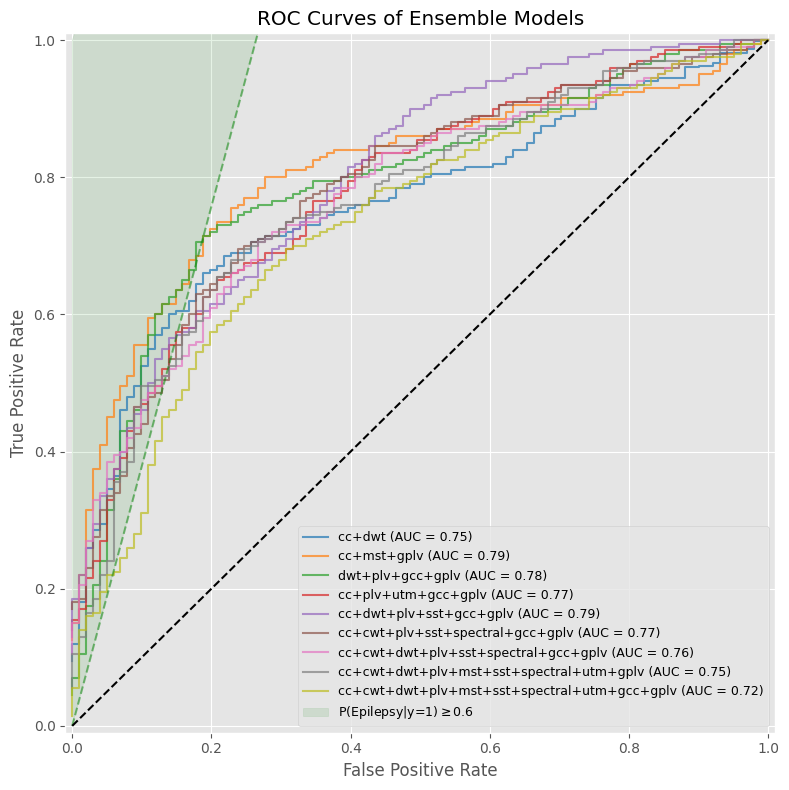

/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_le

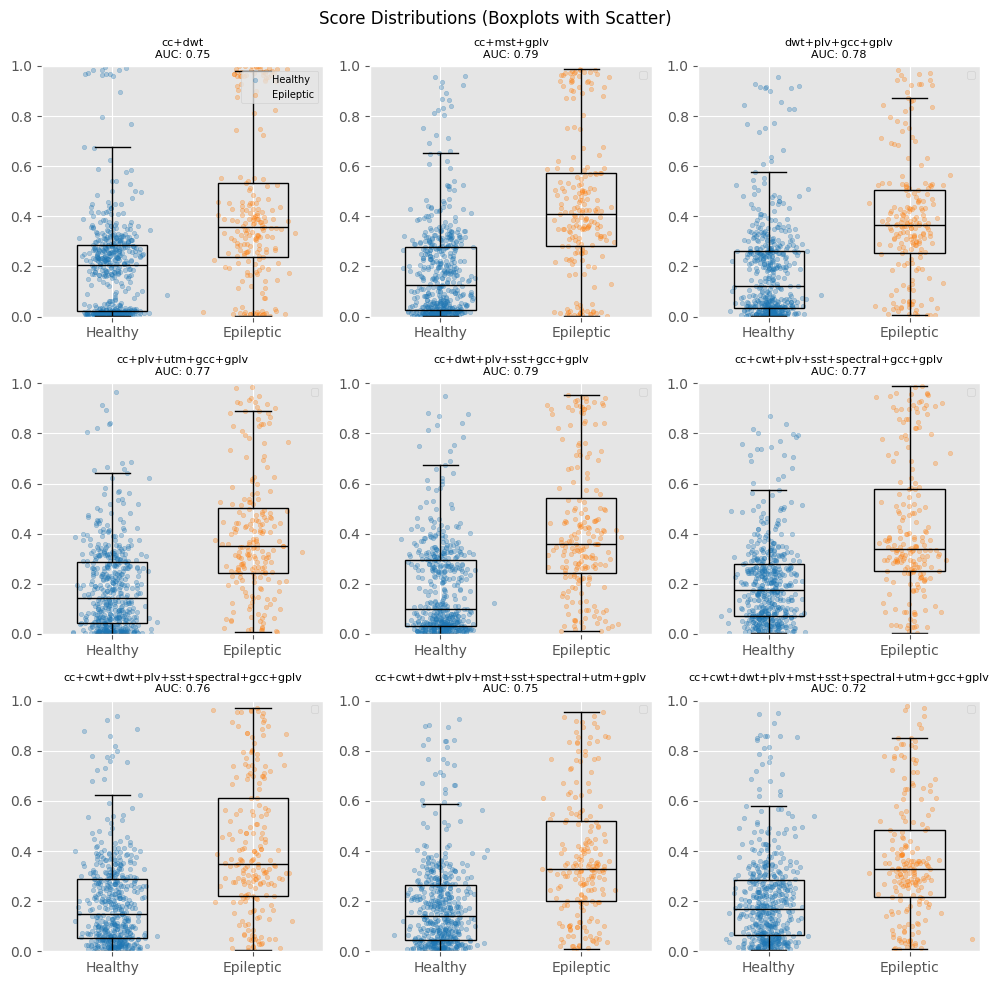


RESULTS FOR: emc_ensemble_retrain
Analyzing data from: /space/gzanardini/emc/emc_ips+bg/
Found 4484 prediction files.

BEST COMBINATIONS WITH STANDARD DEVIATIONS (Mean ± Std)
length         combination      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
     2            gcc+gplv 0.695 ± 0.058 0.684 ± 0.052 0.600 ± 0.071 0.559 ± 0.064 0.491 ± 0.070 0.656 ± 0.088 0.689 ± 0.032 0.488 ± 0.118
     3         cc+utm+gplv 0.713 ± 0.026 0.680 ± 0.028 0.611 ± 0.069 0.550 ± 0.037 0.510 ± 0.039 0.600 ± 0.059 0.709 ± 0.053 0.522 ± 0.024
     4     cc+dwt+plv+gplv 0.698 ± 0.062 0.660 ± 0.045 0.628 ± 0.078 0.529 ± 0.054 0.500 ± 0.093 0.569 ± 0.021 0.707 ± 0.046 0.558 ± 0.035
     5 cc+cwt+dwt+gcc+gplv 0.696 ± 0.080 0.670 ± 0.074 0.584 ± 0.113 0.540 ± 0.101 0.502 ± 0.128 0.605 ± 0.128 0.701 ± 0.059 0.553 ± 0.121

ALTERNATIVE FORMAT: METRICS WITH INTERLEAVED STANDARD DEVIATIONS
length         combination  accuracy  accuracy_std   bac  bac_s

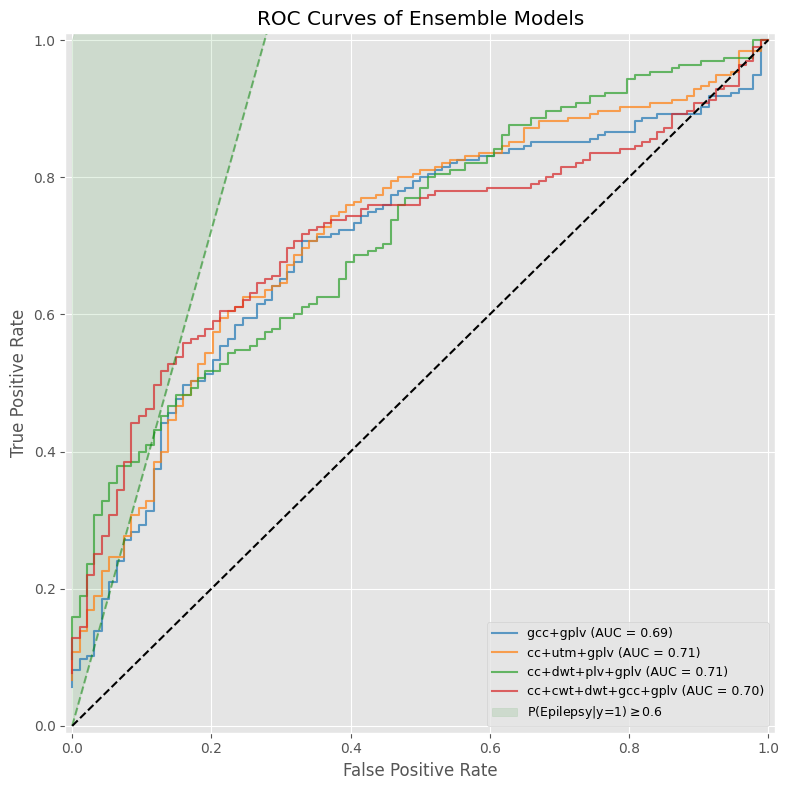

/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_le

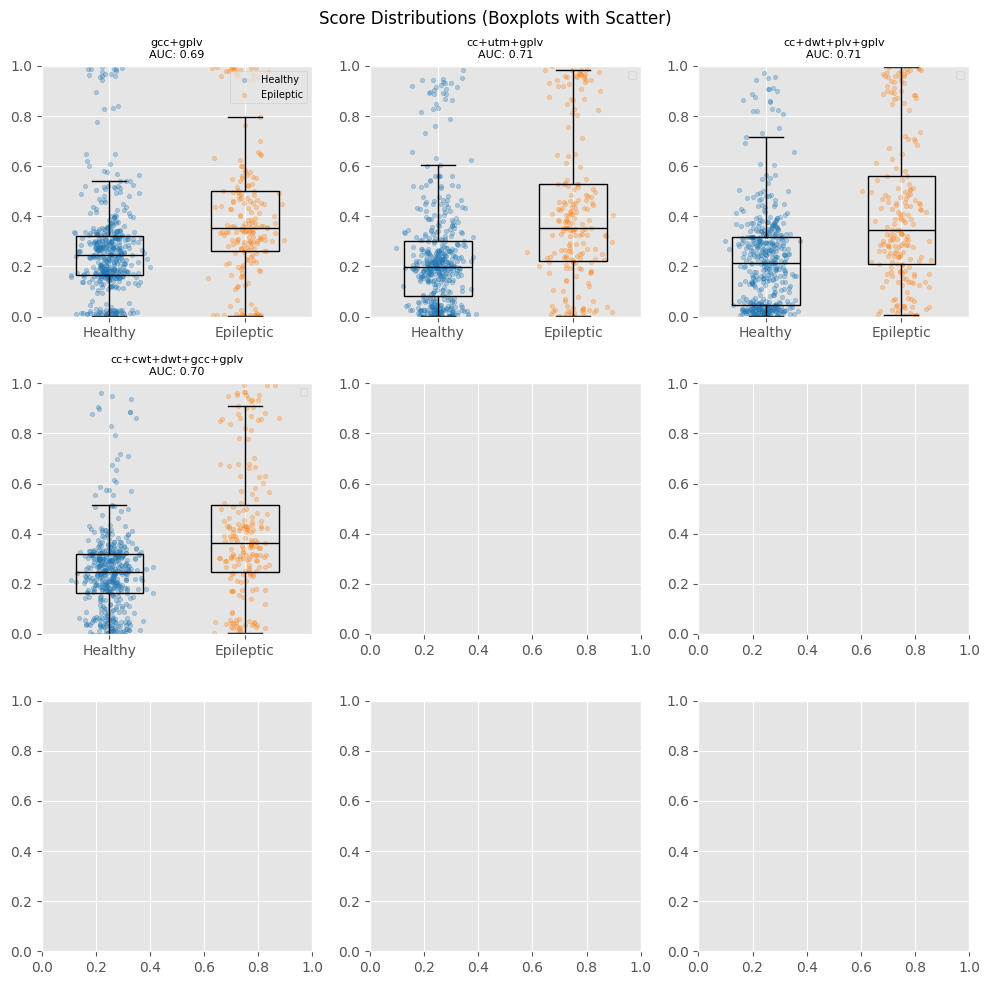


RESULTS FOR: emc_ips+bg
Analyzing data from: /space/gzanardini/tuh/tuh_ensemble_retrain/
Found 10130 prediction files.

BEST COMBINATIONS WITH STANDARD DEVIATIONS (Mean ± Std)
length                                  combination      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
     2                                      mst+gcc 0.795 ± 0.041 0.764 ± 0.039 0.768 ± 0.075 0.683 ± 0.053 0.696 ± 0.086 0.677 ± 0.064 0.850 ± 0.036 0.797 ± 0.045
     3                                   cc+utm+gcc 0.820 ± 0.060 0.815 ± 0.052 0.835 ± 0.069 0.746 ± 0.076 0.704 ± 0.120 0.800 ± 0.042 0.902 ± 0.042 0.797 ± 0.103
     4                               cc+plv+sst+utm 0.840 ± 0.055 0.778 ± 0.090 0.902 ± 0.051 0.694 ± 0.150 0.872 ± 0.086 0.600 ± 0.199 0.936 ± 0.036 0.846 ± 0.108
     5                         cwt+plv+sst+utm+gplv 0.850 ± 0.064 0.793 ± 0.089 0.869 ± 0.041 0.722 ± 0.134 0.898 ± 0.137 0.631 ± 0.184 0.923 ± 0.033 0.840 ± 0.085
   

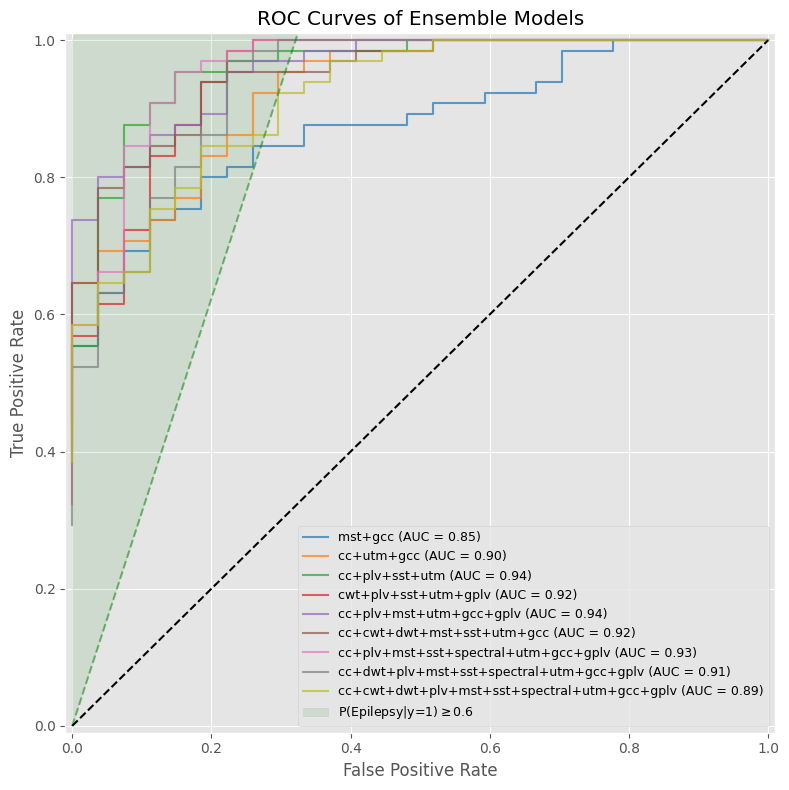

/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_le

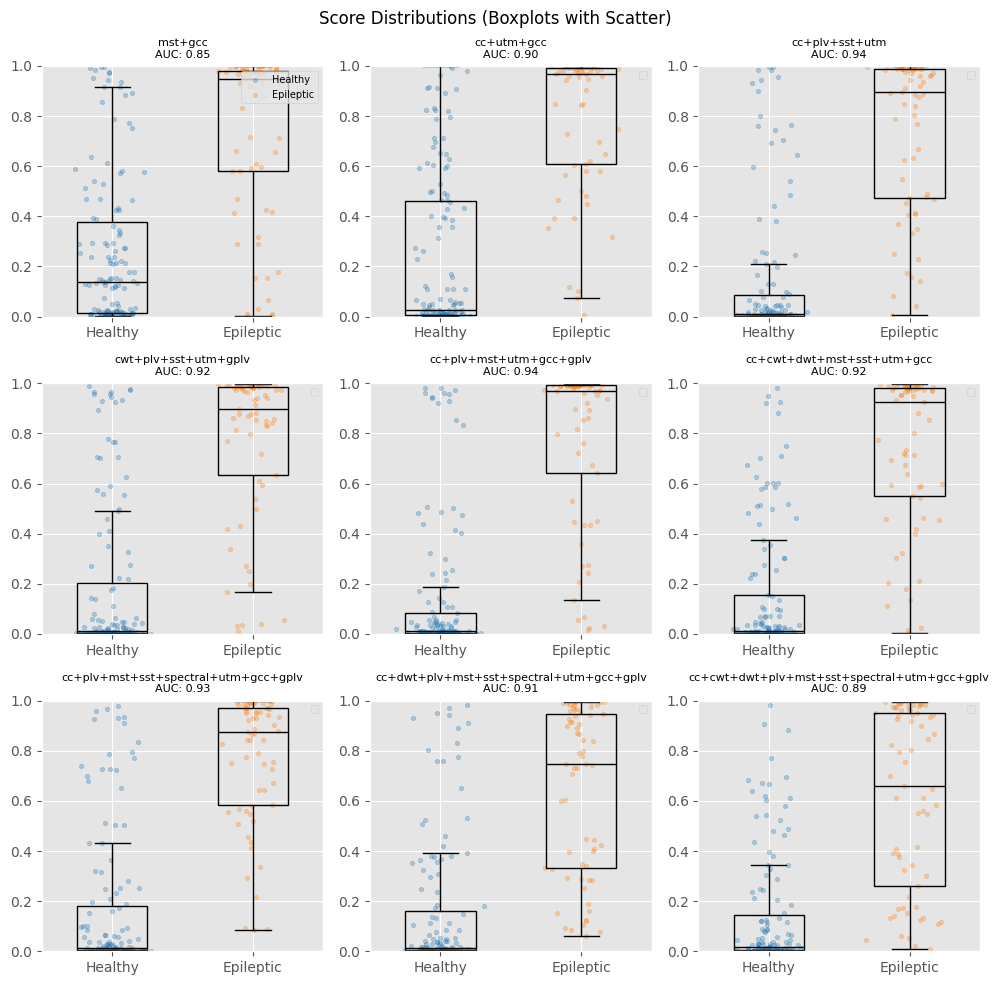


RESULTS FOR: tuh_ensemble_retrain
Analyzing data from: /space/gzanardini/tuh/tuh_ensemble_retrain_noieds/
Found 10130 prediction files.


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



BEST COMBINATIONS WITH STANDARD DEVIATIONS (Mean ± Std)
length                                  combination      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
     2                                      plv+sst 0.832 ± 0.063 0.822 ± 0.056 0.831 ± 0.051 0.737 ± 0.082 0.693 ± 0.120 0.800 ± 0.076 0.885 ± 0.015 0.785 ± 0.059
     3                             mst+sst+spectral 0.853 ± 0.040 0.778 ± 0.056 0.840 ± 0.054 0.700 ± 0.091 0.849 ± 0.105 0.600 ± 0.104 0.897 ± 0.048 0.795 ± 0.081
     4                         plv+sst+spectral+utm 0.858 ± 0.030 0.808 ± 0.052 0.840 ± 0.060 0.734 ± 0.058 0.818 ± 0.126 0.691 ± 0.138 0.901 ± 0.056 0.821 ± 0.075
     5                     cwt+plv+sst+spectral+utm 0.905 ± 0.044 0.847 ± 0.068 0.872 ± 0.057 0.808 ± 0.094 0.960 ± 0.089 0.709 ± 0.135 0.929 ± 0.041 0.866 ± 0.064
     6                plv+sst+spectral+utm+gcc+gplv 0.884 ± 0.024 0.816 ± 0.037 0.838 ± 0.080 0.764 ± 0.055 0.928 ± 0.066 0

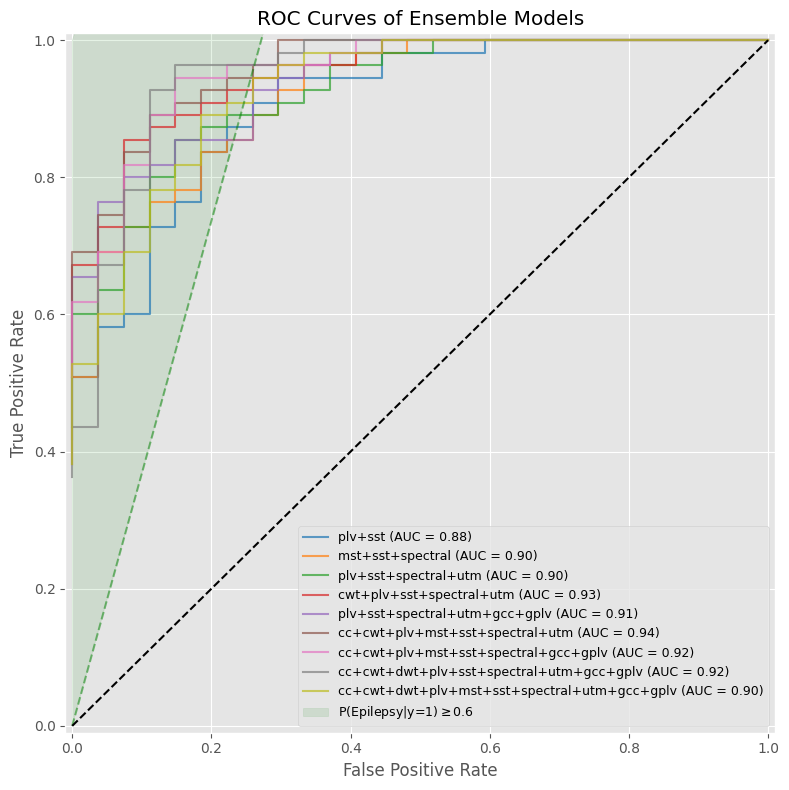

/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_legend_handles_labels()[0])
/tmp/ipykernel_3065179/2005459372.py:218: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax[ax_idx].legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=7, handles=ax[ax_idx].get_le

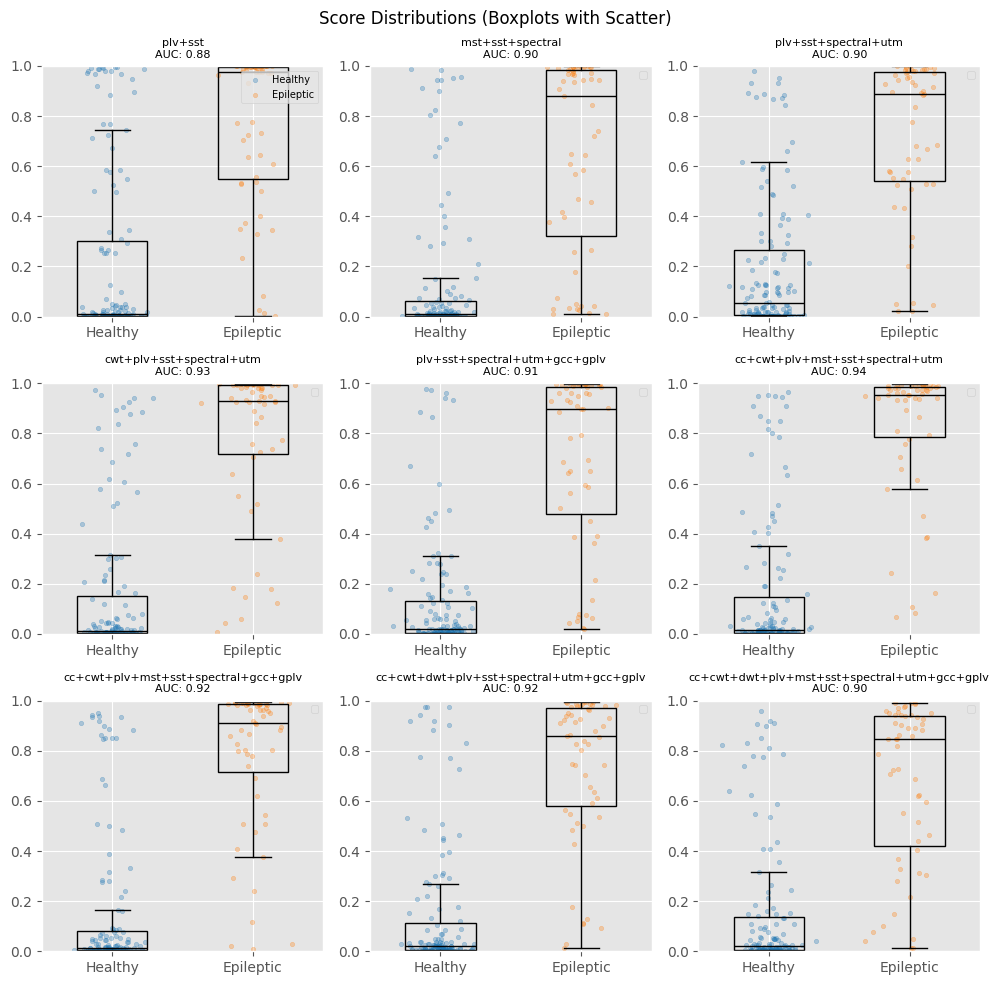


RESULTS FOR: tuh_ensemble_retrain_noieds


In [4]:
for path in available_paths:
    if os.path.exists(path):
        df_summary, df_best, std_df = analyze_ensemble_performance(path, save_plots=True, plot_prefix=os.path.basename(path.rstrip('/')))
        if df_summary is not None:
            print(f"\n{'='*80}")
            print(f"RESULTS FOR: {os.path.basename(path.rstrip('/'))}")
            print(f"{'='*80}")
            # The detailed tables are already printed within the function
    else:
        print(f"Path does not exist: {path}")

## Summary and Next Steps

- The `analyze_ensemble_performance()` function provides a complete analysis pipeline for ensemble performance evaluation.
- It takes a data folder path as input and generates all metrics, tables, and visualizations.
- The function returns summary dataframes for further analysis if needed.
- Use different paths from the `available_paths` list to analyze different datasets.

**Function features:**
- Computes all relevant metrics (AUC, BAC, BAC80, F1, precision, recall, AUPRC, AP)
- Finds best combinations per feature length using composite metric (AUC + BAC80)
- Generates ROC curves, boxplots, and violin plots for visualization
- Saves plots as PDF files with customizable prefixes
- Returns dataframes for further analysis